<a href="https://colab.research.google.com/github/Reben80/Data201/blob/main/DATA_201_WEEK_5B_Demo_Permutation_Treatment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#DATA 201 Week 4B:
##Resampling for Hypothesis Testing:  Permutation Test



Load the libraries we normally use for analysis and visualization.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In this example, we are examining the difference in the survival times for a treatment group and a control group.

What is the null hypothesis in this case?
What is the alternative hypothesis?

Let's define the data for the two groups

In [ ]:
treatment = [94, 197, 16, 38, 99, 141, 23]
control = [52, 104, 146, 10, 51, 30, 40, 27, 46]

The observed difference between the means of the groups is our observed statistic. We are testing whether the observed statistic provides sufficient evidence to reject the null hypothesis.

In [ ]:
#Calculate the observed difference
mean_diff = np.mean(treatment) - np.mean(control)
#mean_diff = treatment.mean() - control.mean()
print (mean_diff)

30.63492063492064


To run the permutation test, we combine both groups into a single dat set.

In [ ]:
#Combine both groups as all_times
#all_times = np.array([treatment, control])
all_times = treatment + control

To begin the permutation test, we initiate the array for the simulated differences, the size of the treatment group, and the number of permutations.  

Why do we need to know group size?

In [ ]:
#Define the array for the simulated differences
simu_diff = []
n_samples = 1000
n_treat = len(treatment)

Now we run the permutations as a for-loop.  Alternately, we could define a function.

In [ ]:
for i in range(n_samples):
#Perform the permutation on all_weights
  perm_sample = np.random.permutation(all_times)
  #Assign the permuted samples to perm_treatment and perm_control
  perm_treatment = perm_sample[:n_treat]
  perm_control = perm_sample[n_treat:]
  perm_diff = np.mean(perm_treatment) - np.mean(perm_control)
  simu_diff.append(perm_diff)

We can calculate and then graph the 95% confidence interval for the simulated differences of means.

In [ ]:
#Use quantiles for define the 95% confidence interval.
upper = np.quantile(simu_diff, 0.95)
lower = np.quantile(simu_diff, 0.05)
print(lower, upper)

-47.33333333333333 46.888888888888886


In [ ]:
#Calculate the p-value
p_value = np.sum(np.abs(simu_diff) >= np.abs(mean_diff)) / 1000
print(f'p-value: {p_value}')


p-value: 0.292


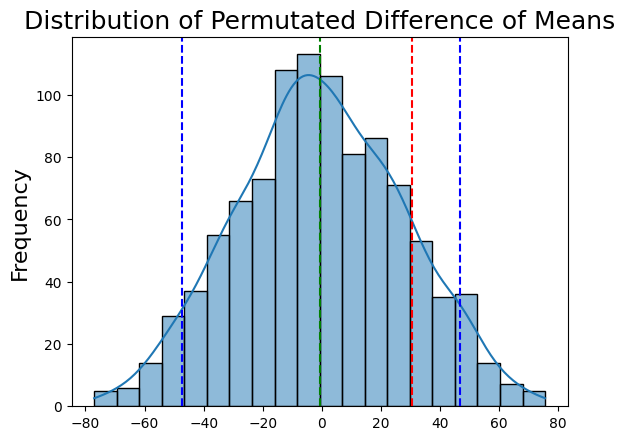

In [ ]:
#Plot the distribution of permutated differences of means (null distribution)
sns.histplot(simu_diff, kde=True, label='Permutation')
plt.axvline(x=np.mean(simu_diff), ymin=0, ymax=1, color='green', linestyle='--')
plt.axvline(x=mean_diff, ymin=0, ymax=1, color='red', linestyle='--')
plt.title('Distribution of Permutated Difference of Means', fontsize=18)
plt.ylabel('Frequency', fontsize=16)

plt.axvline(x=lower, ymin=0, ymax=1, color='blue', linestyle='--')
plt.axvline(x=upper, ymin=0, ymax=1, color='blue', linestyle='--')


In [ ]:
print(f'Permutated Mean Difference: {np.mean(simu_diff):.3}')
print(f'95% Confidence Intervals: [{lower:.3}, {upper:.3}]')
print(f'Actual Difference of Means: {mean_diff:.3}')
print(f'p-value: {p_value:.3}')

Permutated Mean Difference: -0.569
95% Confidence Intervals: [-47.3, 46.9]
Actual Difference of Means: 30.6
p-value: 0.292


Interpretation of Results:

Observed value (actual difference in means) falls within the confidence interval AND the p-value is greater than 5% (.05).  Therefore, we conclude that there is insufficient evidence to reject the null hypothesis.   There is not statistically significant difference between survival rates for the treatment group and the control group.
